### **Mount Drive**

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### **Imports**

In [14]:
import numpy as np
import pandas as pd
import joblib
import time

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

### **Load Preprocessed Data**

In [15]:
DATA_PATH = '/content/drive/MyDrive/CVProject/data/'

X_train = np.load(DATA_PATH + 'X_train.npy')
X_test = np.load(DATA_PATH + 'X_test.npy')

y_train = np.load(DATA_PATH + 'y_train.npy')
y_test = np.load(DATA_PATH + 'y_test.npy')

label_map = joblib.load(DATA_PATH + 'label_encoder.pkl')

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('y_train:', y_train.shape)
print('y_test :', y_test.shape)
print('Classes:', len(label_map))

X_train: (8527, 63)
X_test : (2132, 63)
y_train: (8527,)
y_test : (2132,)
Classes: 28


In [16]:
class_names = [
    label_map[i]
    for i in sorted(label_map.keys())
]

### **Evaluation Function**

In [17]:
results = []

def evaluate_model(model, model_name):

    print(f'\nTraining {model_name}...')

    start = time.time()

    model.fit(X_train, y_train)

    train_time = time.time() - start

    preds = model.predict(X_test)

    accuracy = accuracy_score(y_test, preds)
    precision = precision_score(
        y_test,
        preds,
        average='weighted'
    )
    recall = recall_score(
        y_test,
        preds,
        average='weighted'
    )
    f1 = f1_score(
        y_test,
        preds,
        average='weighted'
    )

    results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'Training Time (s)': train_time
    })

    print(f'Accuracy : {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall   : {recall:.4f}')
    print(f'F1 Score : {f1:.4f}')
    print(f'Time     : {train_time:.2f} sec')

    print('\nClassification Report:')
    print(
    classification_report(
        y_test,
        preds,
        target_names=class_names
    )
)

    return model, preds

### **Train Random Forest**

In [18]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf, rf_preds = evaluate_model(
    rf,
    'Random Forest'
)


Training Random Forest...
Accuracy : 0.9784
Precision: 0.9793
Recall   : 0.9784
F1 Score : 0.9785
Time     : 24.30 sec

Classification Report:
              precision    recall  f1-score   support

           A       0.99      0.99      0.99        76
           B       0.95      1.00      0.97        73
           C       1.00      1.00      1.00        64
           D       0.99      1.00      0.99        83
           E       0.96      1.00      0.98        77
           F       1.00      0.98      0.99        97
           G       0.99      1.00      0.99        77
           H       1.00      0.98      0.99        84
           I       1.00      0.92      0.96        79
           J       0.98      1.00      0.99        84
           K       1.00      1.00      1.00        91
           L       0.99      0.98      0.98        86
           M       0.81      0.95      0.87        58
           N       0.89      0.79      0.84        43
           O       0.99      1.00      0.99  

### **Train Svm**

In [19]:
svm = SVC(
    kernel='rbf',
    C=10,
    gamma='scale'
)

svm, svm_preds = evaluate_model(
    svm,
    'SVM'
)


Training SVM...
Accuracy : 0.9841
Precision: 0.9845
Recall   : 0.9841
F1 Score : 0.9841
Time     : 0.64 sec

Classification Report:
              precision    recall  f1-score   support

           A       1.00      0.97      0.99        76
           B       0.99      0.99      0.99        73
           C       1.00      1.00      1.00        64
           D       1.00      1.00      1.00        83
           E       0.97      1.00      0.99        77
           F       0.99      0.99      0.99        97
           G       1.00      1.00      1.00        77
           H       1.00      1.00      1.00        84
           I       1.00      0.94      0.97        79
           J       0.98      1.00      0.99        84
           K       1.00      1.00      1.00        91
           L       1.00      0.99      0.99        86
           M       0.86      0.95      0.90        58
           N       0.88      0.84      0.86        43
           O       1.00      1.00      1.00        76
  

### **Train MLP**

In [20]:
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=100,
    random_state=42
)

mlp, mlp_preds = evaluate_model(
    mlp,
    'MLP'
)


Training MLP...
Accuracy : 0.9808
Precision: 0.9814
Recall   : 0.9808
F1 Score : 0.9809
Time     : 14.24 sec

Classification Report:
              precision    recall  f1-score   support

           A       1.00      0.97      0.99        76
           B       0.99      0.99      0.99        73
           C       0.98      1.00      0.99        64
           D       1.00      1.00      1.00        83
           E       1.00      1.00      1.00        77
           F       0.99      0.97      0.98        97
           G       0.96      1.00      0.98        77
           H       1.00      0.99      0.99        84
           I       1.00      0.94      0.97        79
           J       0.97      0.99      0.98        84
           K       1.00      1.00      1.00        91
           L       1.00      0.98      0.99        86
           M       0.87      0.93      0.90        58
           N       0.88      0.88      0.88        43
           O       1.00      0.99      0.99        76
 

### **Compare Models**

In [21]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='Accuracy',
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,Training Time (s)
1,SVM,0.984053,0.984536,0.984053,0.984117,0.641462
2,MLP,0.980769,0.981369,0.980769,0.980894,14.237447
0,Random Forest,0.978424,0.979296,0.978424,0.978497,24.300886


### **Plot Accuracy**

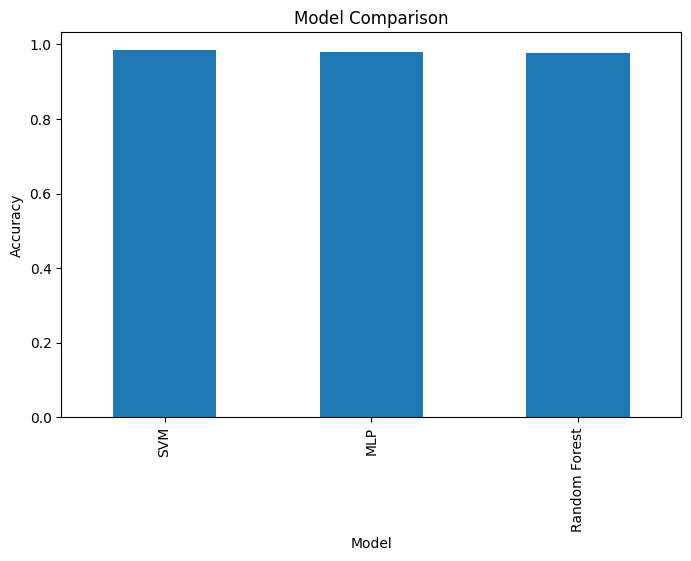

In [22]:
results_df.plot(
    x='Model',
    y='Accuracy',
    kind='bar',
    legend=False,
    figsize=(8,5)
)

plt.ylabel('Accuracy')
plt.title('Model Comparison')
plt.show()

### **Confusion Matrix of best Model**

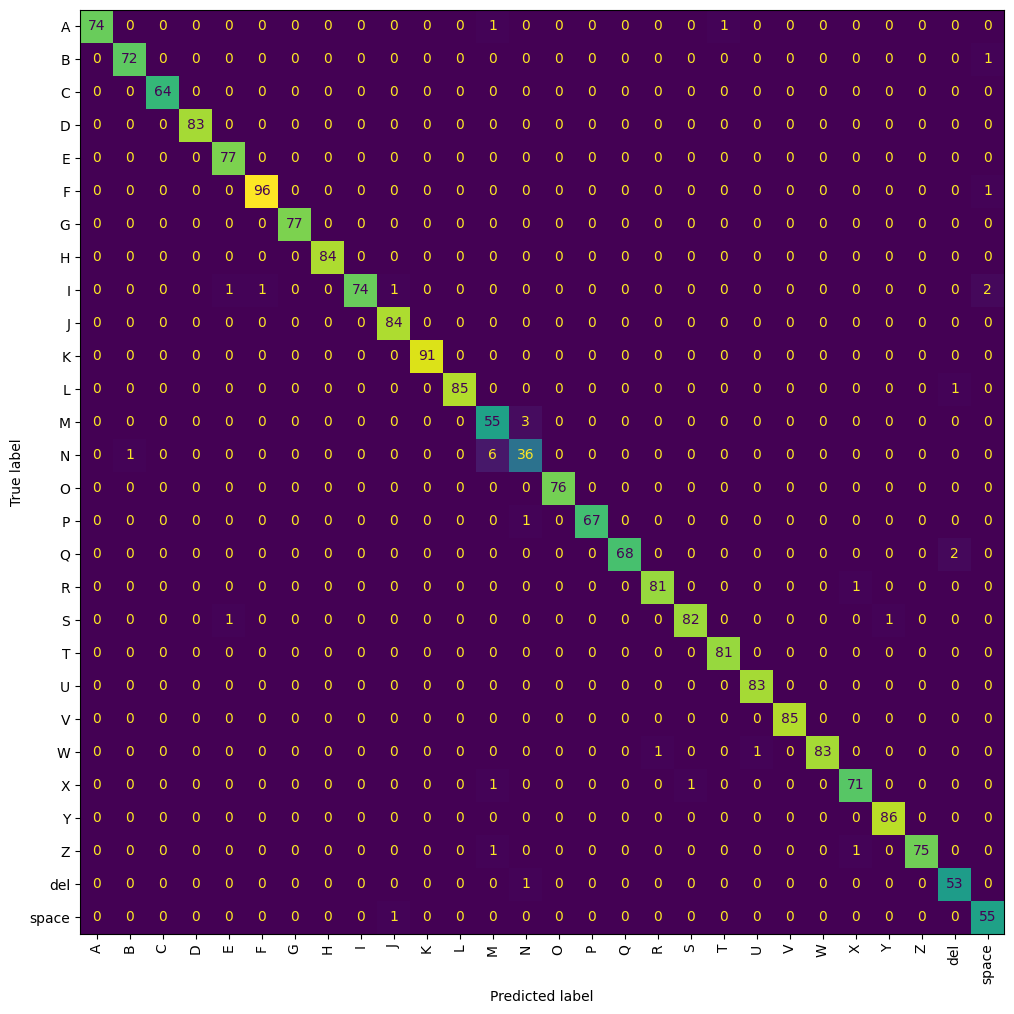

In [23]:
cm = confusion_matrix(
    y_test,
    svm_preds
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(
    figsize=(12,12)
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    colorbar=False
)

plt.show()

### **Save Models**

In [25]:
MODEL_PATH = '/content/drive/MyDrive/CVProject/models/'

joblib.dump(
    rf,
    MODEL_PATH + 'random_forest.pkl'
)

joblib.dump(
    svm,
    MODEL_PATH + 'svm.pkl'
)

joblib.dump(
    mlp,
    MODEL_PATH + 'mlp.pkl'
)

print('Models saved.')

Models saved.
